# 14 · Restatement alpha: share prices after a downward restatement

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/14_restatement_alpha.ipynb)

**What you will learn**

- How to turn the restatement feed into dated events that an investor could have acted on.
- How to run a simple event study: returns after each event, measured against the index average
  over the same months.
- Whether announced (`non_reliance` or `amended`) and unannounced (`undisclosed`) downward
  revisions were followed by different returns.

**Plan required:** none (free sample tier: S&P 500 companies, month-end prices for the last five
years). The same code on Benchmark covers 1993 onward, and on Pro and Institutional the whole
US market.

In [1]:
%pip install -q valuein-sdk matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Events an investor could have seen

Each row of `restatement_events` is a number revised by a later filing. The revision became
public when that filing was accepted (`last_filed_at`), so that is the event date; using the
period it describes would look into the future.

We keep downward revisions of at least 5% to net income or revenue, in US dollars (bounded
below 90% to skip scale artifacts), and collapse several revised numbers in one filing into one
event per company and filing date. The feed covers every company, so the counts below include
companies outside your plan's price data; section 2 keeps the ones it can price.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from valuein_sdk import ValueinClient

client = ValueinClient()

events = client.run_query("""
    SELECT cik, any_value(ticker) AS ticker,
           CASE WHEN bool_and(disclosure_class = 'undisclosed') THEN 'undisclosed'
                ELSE 'announced' END AS disclosure,
           CAST(last_filed_at AS DATE) AS event_date,
           min(delta_pct) AS worst_change
    FROM restatement_events
    WHERE standard_concept IN ('NetIncome', 'TotalRevenue')
      AND unit = 'USD'
      AND delta_pct BETWEEN -0.90 AND -0.05
      AND last_filed_at BETWEEN TIMESTAMP '2021-03-01' AND TIMESTAMP '2026-03-31'
    GROUP BY cik, CAST(last_filed_at AS DATE)
""")
events["event_date"] = pd.to_datetime(events["event_date"])
events.groupby("disclosure").agg(events=("cik", "size"), companies=("cik", "nunique"))


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


,events,companies
disclosure,,
announced,370,293
undisclosed,1262,691


Here `announced` groups `non_reliance` and `amended` (an Item 4.02 or an amended report) and
`undisclosed` is a change inside a routine 10-K or 10-Q.

## 2. Returns around each event

For every event: the month-end close **before** the filing is the base, then the return to each
of the next six month-end closes, from `total_return_index` (dividends and splits included).
The abnormal return subtracts the equal-weight average of all priced companies over the same
months, which removes the market's own moves.

In [3]:
bars = client.run_query("""
    SELECT entity_id AS cik, price_date, total_return_index AS tri
    FROM stock_price
    WHERE observation = 'monthly' AND total_return_index IS NOT NULL
    QUALIFY ROW_NUMBER() OVER (PARTITION BY entity_id, price_date ORDER BY security_id) = 1
""")
bars["month"] = pd.to_datetime(bars["price_date"]).dt.to_period("M")
prices = bars.pivot_table(index="month", columns="cik", values="tri")
market = prices.pct_change().mean(axis=1)  # equal-weight average monthly return

HORIZON = 6
rows = []
for event in events[events["cik"].isin(prices.columns)].itertuples():
    base_month = event.event_date.to_period("M") - 1
    if base_month not in prices.index:
        continue
    path = prices[event.cik].loc[base_month:].iloc[: HORIZON + 1]
    if len(path) < HORIZON + 1 or path.isna().any():
        continue
    stock = path / path.iloc[0] - 1
    index = (1 + market.loc[path.index[1:]]).cumprod() - 1
    abnormal = stock.iloc[1:].values - index.values
    rows.append({"disclosure": event.disclosure, "ticker": event.ticker,
                 **{f"m{k}": abnormal[k - 1] for k in range(1, HORIZON + 1)}})

car = pd.DataFrame(rows)
print(f"events at companies with prices in this plan: {events['cik'].isin(prices.columns).sum()}")
print(f"of which with six month-ends of prices after the filing: {len(car)}")

events at companies with prices in this plan: 162
of which with six month-ends of prices after the filing: 162


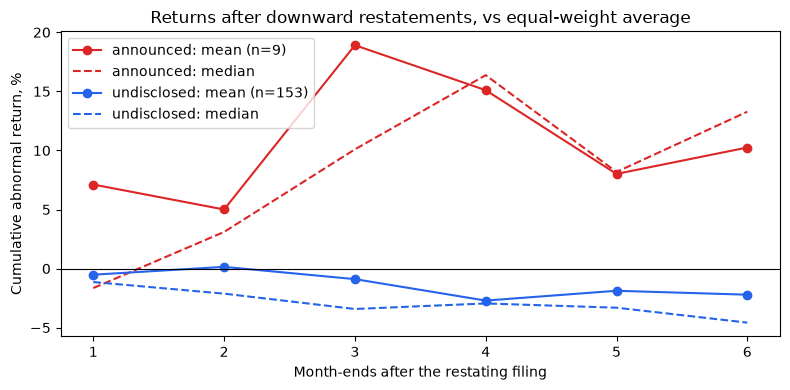

,m1,m2,m3,m4,m5,m6
disclosure,,,,,,
announced,7.12,5.00,18.91,15.10,8.01,10.25
undisclosed,-0.52,0.15,-0.89,-2.71,-1.88,-2.21


In [4]:
months = [f"m{k}" for k in range(1, HORIZON + 1)]
mean_car = car.groupby("disclosure")[months].mean() * 100
median_car = car.groupby("disclosure")[months].median() * 100
counts = car.groupby("disclosure").size()

fig, ax = plt.subplots(figsize=(8, 4))
for (cls, mean), color in zip(mean_car.iterrows(), ["#dc2626", "#2563eb"]):
    ax.plot(range(1, HORIZON + 1), mean.values, marker="o", color=color, label=f"{cls}: mean (n={counts[cls]})")
    ax.plot(range(1, HORIZON + 1), median_car.loc[cls].values, linestyle="--", color=color, label=f"{cls}: median")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Month-ends after the restating filing")
ax.set_ylabel("Cumulative abnormal return, %")
ax.set_title("Returns after downward restatements, vs equal-weight average")
ax.legend()
plt.tight_layout()
plt.show()

mean_car.round(2)

## 3. How much to trust this

- The sample is small and covers one index over a few years. Look at the spread, not only the
  mean: a few large moves can carry an average.

In [5]:
spread = car.groupby("disclosure")["m6"].describe(percentiles=[0.25, 0.5, 0.75])
spread[["mean", "std", "25%", "50%", "75%", "min", "max"]] *= 100
spread.round(1)

,count,mean,std,min,25%,50%,75%,max
disclosure,,,,,,,,
announced,9.0,10.2,16.2,-17.7,1.2,13.3,17.1,32.9
undisclosed,153.0,-2.2,29.0,-57.1,-16.5,-4.6,7.8,206.8


- Month-end prices add up to a month of noise between the filing and the base price.
- Events overlap in time and cluster by company, so they are not independent observations.

Treat this as a research starting point. A sturdier test uses daily bars (Pro, Institutional)
to measure from the filing day, a longer history (Benchmark and above), and the full market
including the small companies where restatements are more frequent (Pro and Institutional).

In [6]:
client.close()

## Next steps

- **[15 · Capital allocation](15_capital_allocation.ipynb)**.
- Notebook 06 explains each `disclosure_class` and shows how to verify a revision on sec.gov.